In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os
import torch
import seaborn as sns
import copy

In [2]:
import sys
sys.path.append('../code/BalancingControl')
import tmaze_utils as tu
import inference_utils as iu
import inference as inf

import misc

Running on device cpu
torch threads 1


In [3]:
groups = ["control", "cie"]

agents = ["BCC_2pars_planning_repetition_weight"]

In [4]:
results_dir = os.path.abspath('results')
inference_folder = os.path.join(results_dir, "inference")
print(inference_folder)

c:\Users\sarah\Documents\GitHub\TMaze\cie_task\results\inference


In [5]:
results = {}
data = {}
n_agents = {}
num_steps = 600

for grp in groups:
    base_dir = "processed_data"
    fname_data = os.path.join(base_dir, f"TMaze_{grp}_structured_data.json")
    structured_data = misc.load_file(fname_data, fname_data)
    data[grp] = structured_data
    n_agents[grp] = len(structured_data["subject"][0])
    for agt in agents:
        fname_base = agt+"_"+grp+"_inference_"
        fname_str = fname_base + str(num_steps)+'_'+str(n_agents[grp])+'agents'
        # define folder where we want to save data
        base_dir = os.path.join(inference_folder,fname_base[:-1])
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 
        print(f"{agt}_{grp}")
        results[f"{agt}_{grp}"] = {}
        results[f"{agt}_{grp}"]["mean_df"] = mean_df
        results[f"{agt}_{grp}"]["sample_df"] = sample_df
        results[f"{agt}_{grp}"]["locs_df"] = locs_df

BCC_2pars_planning_repetition_weight_control
BCC_2pars_planning_repetition_weight_cie


In [6]:
base_dir = "processed_data"
fname_plot_df = os.path.join(base_dir, "plot_df.csv")
plot_df = pd.read_csv(fname_plot_df)

In [7]:
plot_df["correct"][plot_df["trial_type"]=="early test"]

75      0.0
76      0.0
77      0.0
78      1.0
79      0.0
       ... 
2315    0.0
2316    0.0
2317    0.0
2318    1.0
2319    0.0
Name: correct, Length: 75, dtype: float64

In [8]:
plot_df[plot_df["trial_type"]=="early test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    control    0.4
24.0    cie        0.2
25.0    cie        0.2
26.0    cie        0.2
27.0    cie        0.4
32.0    cie        0.4
33.0    cie        0.0
34.0    cie        0.2
35.0    cie        0.2
38.0    control    0.6
39.0    control    0.4
44.0    control    0.2
45.0    control    0.2
46.0    control    1.0
47.0    control    0.6
Name: correct, dtype: float64

In [9]:
plot_df[plot_df["trial_type"]=="late test"].groupby(["animal", "group"])["correct"].mean()

animal  group  
20.0    control    0.4
24.0    cie        0.4
25.0    cie        0.4
26.0    cie        0.2
27.0    cie        0.8
32.0    cie        0.6
33.0    cie        0.2
34.0    cie        0.8
35.0    cie        0.6
38.0    control    0.8
39.0    control    0.4
44.0    control    0.6
45.0    control    1.0
46.0    control    0.2
47.0    control    0.8
Name: correct, dtype: float64

In [10]:
print(results.keys())
results[agents[0]+"_cie"]

dict_keys(['BCC_2pars_planning_repetition_weight_control', 'BCC_2pars_planning_repetition_weight_cie'])


{'mean_df':    Unnamed: 0  inferred dec temp  subject  inferred habitual tendency
 0           0           0.696479        0                    1.738869
 1           1           1.785011        1                    4.373709
 2           2           0.867470        2                    2.203062
 3           3           2.950877        3                    1.873015
 4           4           0.842553        4                    2.380835
 5           5           0.984952        5                    5.206596
 6           6           1.545360        6                    2.200152
 7           7           1.798345        7                    2.932678,
 'sample_df':       Unnamed: 0  dec temp  habitual tendency  subject
 0              0  0.572668           4.450566        0
 1              1  1.196745           1.713011        1
 2              2  1.266276           1.276701        2
 3              3  3.496034           1.105047        3
 4              4  0.495879           4.132788        4


In [11]:
cie_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values

cie_dec_temp = results[agents[0]+"_cie"]["mean_df"]["inferred dec temp"]
cie_hab_tend = results[agents[0]+"_cie"]["mean_df"]["inferred habitual tendency"]

C:\Users\sarah\AppData\Local\Temp\ipykernel_5768\3176153628.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_5768\3176153628.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values


In [12]:
cie_dict = {"early acc": cie_early_accuracy, "late acc": cie_late_accuracy, "dec temp": cie_dec_temp, "hab tend": cie_hab_tend}

cie_df = pd.DataFrame(cie_dict)

In [13]:
cie_df.corr()

,early acc,late acc,dec temp,hab tend
early acc,1.000000,0.652753,0.406077,-0.674637
late acc,0.652753,1.000000,0.640791,-0.512244
dec temp,0.406077,0.640791,1.000000,-0.087697
hab tend,-0.674637,-0.512244,-0.087697,1.000000


In [14]:
control_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values

control_dec_temp = results[agents[0]+"_control"]["mean_df"]["inferred dec temp"]
control_hab_tend = results[agents[0]+"_control"]["mean_df"]["inferred habitual tendency"]

C:\Users\sarah\AppData\Local\Temp\ipykernel_5768\3698181728.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_5768\3698181728.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_late_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values


In [15]:
control_dict = {"early acc": control_early_accuracy, "late acc": control_late_accuracy, "dec temp": control_dec_temp, "hab tend": control_hab_tend}

control_df = pd.DataFrame(control_dict)

In [16]:
control_df.corr()

,early acc,late acc,dec temp,hab tend
early acc,1.000000,-0.506061,-0.171730,0.091173
late acc,-0.506061,1.000000,0.178879,-0.377612
dec temp,-0.171730,0.178879,1.000000,0.331873
hab tend,0.091173,-0.377612,0.331873,1.000000


In [17]:
from scipy.stats import ttest_ind

In [18]:
ttest_ind(control_dec_temp, cie_dec_temp)

TtestResult(statistic=np.float64(-1.7792720104549853), pvalue=np.float64(0.09857142799642468), df=np.float64(13.0))

In [19]:
ttest_ind(control_hab_tend, cie_hab_tend)

TtestResult(statistic=np.float64(-0.8557805508832954), pvalue=np.float64(0.40761617136744016), df=np.float64(13.0))

In [20]:
from scipy.stats import pearsonr

In [21]:
print("p val control dec temp & hab tend")
print(pearsonr(control_dec_temp, control_hab_tend))

print("p val control early acc & dec temp")
print(pearsonr(control_early_accuracy, control_dec_temp))

print("p val control late acc & dec temp")
print(pearsonr(control_late_accuracy, control_dec_temp))

print("p val control early acc & hab tend")
print(pearsonr(control_early_accuracy, control_hab_tend))

print("p val control late acc & hab tend")
print(pearsonr(control_late_accuracy, control_hab_tend))

p val control dec temp & hab tend
PearsonRResult(statistic=np.float64(0.3318734796057426), pvalue=np.float64(0.4671013077502338))
p val control early acc & dec temp
PearsonRResult(statistic=np.float64(-0.17172966609978932), pvalue=np.float64(0.7127424552284353))
p val control late acc & dec temp
PearsonRResult(statistic=np.float64(0.1788790125419999), pvalue=np.float64(0.7011605902028302))
p val control early acc & hab tend
PearsonRResult(statistic=np.float64(0.09117280530549447), pvalue=np.float64(0.8458627374656273))
p val control late acc & hab tend
PearsonRResult(statistic=np.float64(-0.37761204437954504), pvalue=np.float64(0.40365523277506404))


In [22]:
print("p val cie dec temp & hab tend")
print(pearsonr(cie_dec_temp, cie_hab_tend))

print("p val cie early acc & dec temp")
print(pearsonr(cie_early_accuracy, cie_dec_temp))

print("p val cie late acc & dec temp")
print(pearsonr(cie_late_accuracy, cie_dec_temp))

print("p val cie early acc & hab tend")
print(pearsonr(cie_early_accuracy, cie_hab_tend))

print("p val cie late acc & hab tend")
print(pearsonr(cie_late_accuracy, cie_hab_tend))

p val cie dec temp & hab tend
PearsonRResult(statistic=np.float64(-0.08769653480714518), pvalue=np.float64(0.8364101098558216))
p val cie early acc & dec temp
PearsonRResult(statistic=np.float64(0.40607703836970865), pvalue=np.float64(0.31816675538684325))
p val cie late acc & dec temp
PearsonRResult(statistic=np.float64(0.6407909332829179), pvalue=np.float64(0.08689863539309187))
p val cie early acc & hab tend
PearsonRResult(statistic=np.float64(-0.6746371827362914), pvalue=np.float64(0.06646310600856431))
p val cie late acc & hab tend
PearsonRResult(statistic=np.float64(-0.5122438515434988), pvalue=np.float64(0.1943291788567513))


In [23]:
print(np.append(control_early_accuracy, cie_early_accuracy).shape)

print(cie_early_accuracy.shape)

(15,)
(8,)


In [24]:
control_omega = control_dec_temp / (control_dec_temp + control_hab_tend)

control_beta = (control_dec_temp + control_hab_tend)

cie_omega = cie_dec_temp / (cie_dec_temp + cie_hab_tend)

cie_beta = (cie_dec_temp + cie_hab_tend)

In [25]:
ttest_ind(control_omega, cie_omega)

TtestResult(statistic=np.float64(-0.7736225741404233), pvalue=np.float64(0.45299307985706216), df=np.float64(13.0))

In [26]:
ttest_ind(control_beta, cie_beta)

TtestResult(statistic=np.float64(-1.5197982246528956), pvalue=np.float64(0.15250380267096256), df=np.float64(13.0))

In [27]:
group_comp_dict = {"group": ["control"]*n_agents["control"]+["cie"]*n_agents["cie"], "early acc": np.append(control_early_accuracy, cie_early_accuracy), 
                   "late acc": np.append(control_late_accuracy, cie_late_accuracy), "dec temp": np.append(control_dec_temp, cie_dec_temp), "hab tend": np.append(control_hab_tend,cie_hab_tend),
                   "omega": np.append(control_omega, cie_omega), "beta": np.append(control_beta, cie_beta)}

group_comp_df = pd.DataFrame(group_comp_dict)

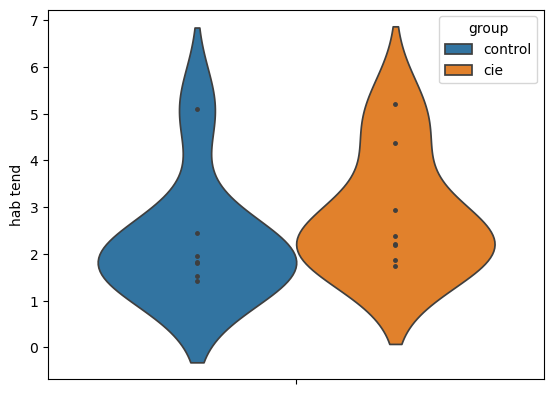

In [28]:
plt.figure()
sns.violinplot(data=group_comp_df, y="hab tend", hue="group", inner="point")
plt.show()

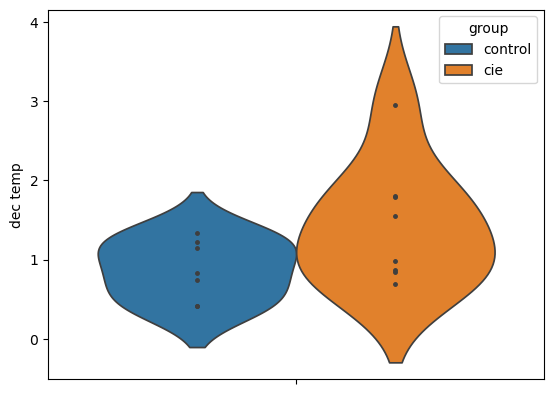

In [29]:
plt.figure()
sns.violinplot(data=group_comp_df, y="dec temp", hue="group", inner="point")
plt.show()

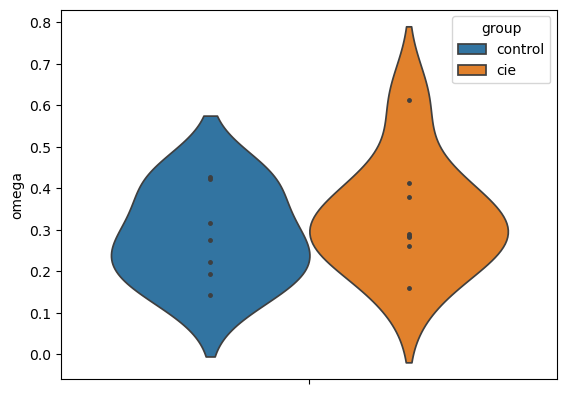

In [30]:
plt.figure()
sns.violinplot(data=group_comp_df, y="omega", hue="group", inner="point")
plt.show()

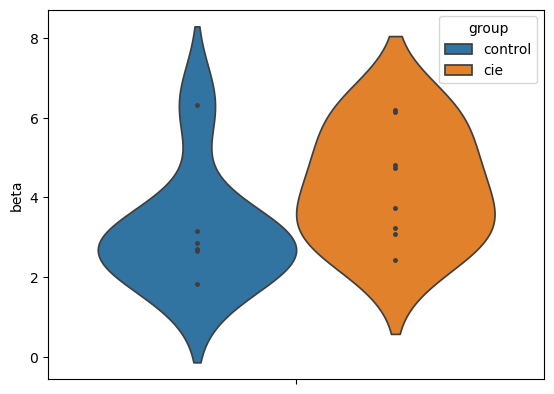

In [31]:
plt.figure()
sns.violinplot(data=group_comp_df, y="beta", hue="group", inner="point")
plt.show()

<Figure size 640x480 with 0 Axes>

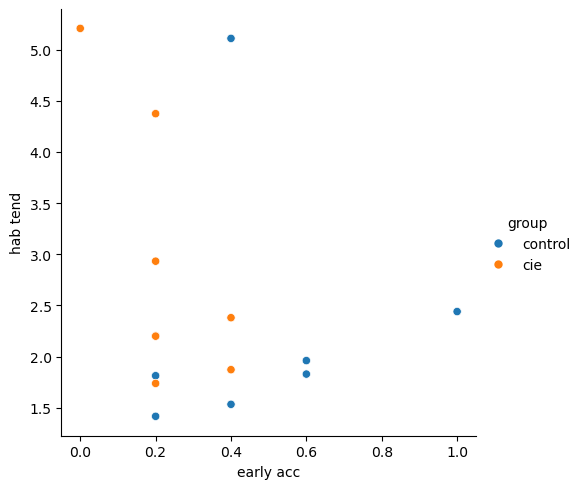

<Figure size 640x480 with 0 Axes>

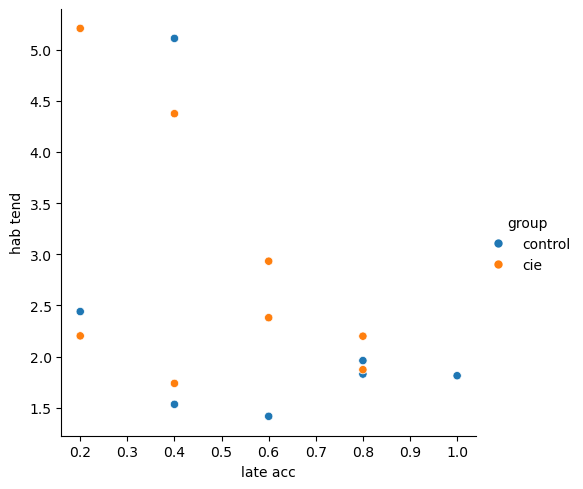

In [32]:
plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="early acc", hue="group")
plt.show()

plt.figure()
sns.relplot(data=group_comp_df, y="hab tend", x="late acc", hue="group")
plt.show()

<Figure size 640x480 with 0 Axes>

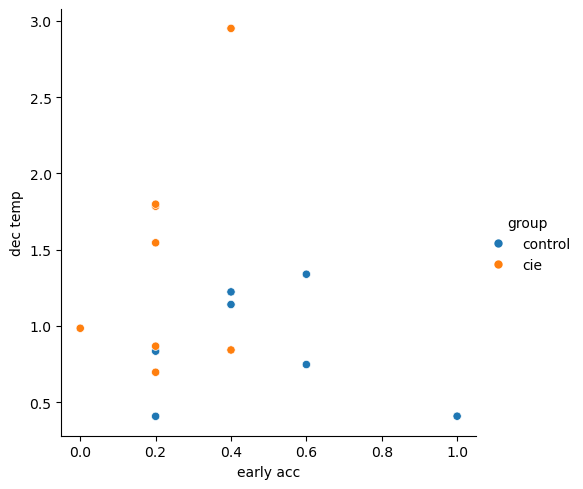

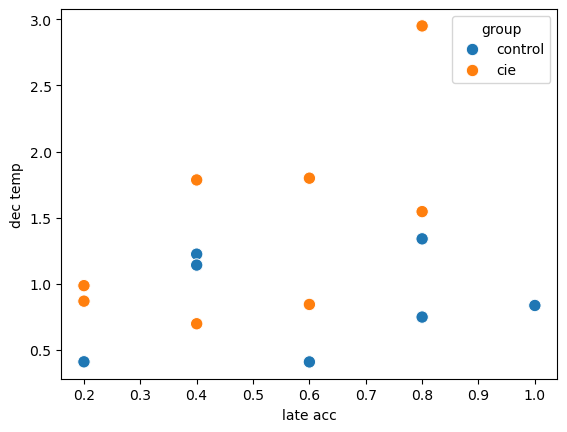

In [33]:
plt.figure()
sns.relplot(data=group_comp_df, y="dec temp", x="early acc", hue="group", sizes=(5))
plt.show()

plt.figure()
sns.scatterplot(data=group_comp_df, y="dec temp", x="late acc", hue="group", marker="o", s=80)#sizes=(200,200))
plt.show()